<a href="https://colab.research.google.com/github/Sheriff414/my_deeplearning_model/blob/master/my_real_kd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install einops

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 670.9 kB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from einops.layers.torch import Reduce

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyper-parameters
num_epochs = 3
batch_size = 4
learning_rate = 0.001

# dataset has PILImage images of range [0, 1].
# We transform them to Tensors of normalized range [-1, 1]
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170498071/170498071 [00:13<00:00, 12708876.05it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


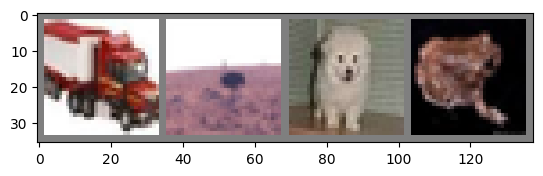

In [ ]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))


In [ ]:
#Teacher model
model=torchvision.models.resnet18(pretrained=True)
num_ftrs=model.fc.in_features
model.fc=nn.Linear(num_ftrs, 10)
bmodel = model.to(device)
#print(bmodel)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(bmodel.parameters(), lr=learning_rate)
n_total_steps = len(train_loader)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]


In [ ]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # origin shape: [4, 3, 32, 32] = 4, 3, 1024
        # input_layer: 3 input channels, 6 output channels, 5 kernel size
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = bmodel(images)
        #print(images.shape)
        #print(outputs.shape)
        loss = criterion(outputs, labels)
        #break
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 2000 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

print('Finished Training')
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)

Epoch [1/3], Step [2000/12500], Loss: 1.5000
Epoch [1/3], Step [4000/12500], Loss: 2.3981
Epoch [1/3], Step [6000/12500], Loss: 0.7097
Epoch [1/3], Step [8000/12500], Loss: 1.2094
Epoch [1/3], Step [10000/12500], Loss: 1.6621
Epoch [1/3], Step [12000/12500], Loss: 1.5725
Epoch [2/3], Step [2000/12500], Loss: 1.8154
Epoch [2/3], Step [4000/12500], Loss: 2.3295
Epoch [2/3], Step [6000/12500], Loss: 1.5339
Epoch [2/3], Step [8000/12500], Loss: 1.7986
Epoch [2/3], Step [10000/12500], Loss: 1.5288
Epoch [2/3], Step [12000/12500], Loss: 0.5587
Epoch [3/3], Step [2000/12500], Loss: 0.7112
Epoch [3/3], Step [4000/12500], Loss: 2.3319
Epoch [3/3], Step [6000/12500], Loss: 1.3521
Epoch [3/3], Step [8000/12500], Loss: 1.2591
Epoch [3/3], Step [10000/12500], Loss: 2.8674
Epoch [3/3], Step [12000/12500], Loss: 0.6496
Finished Training


In [ ]:

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = bmodel(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

        for i in range(batch_size):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    for i in range(10):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Accuracy of {classes[i]}: {acc} %')


Accuracy of the network: 62.06 %
Accuracy of plane: 65.0 %
Accuracy of car: 81.7 %
Accuracy of bird: 47.9 %
Accuracy of cat: 27.5 %
Accuracy of deer: 61.7 %
Accuracy of dog: 65.9 %
Accuracy of frog: 70.6 %
Accuracy of horse: 66.2 %
Accuracy of ship: 68.6 %
Accuracy of truck: 65.5 %


In [ ]:
# smodel=torchvision.models.alexnet()
# del smodel.features[12]
# smodel.classifier[6]=nn.Linear(50, 10)
# print(smodel)
# smodel = smodel.to(device)

class Smodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.in_layer = nn.Linear(32, 784)
        self.linear_1 = nn.Linear(784, 50)
        self.relu = nn.ReLU()
        self.linear_2 = nn.Linear(50, 10)
        self.reduce = Reduce('b n h w -> b w', reduction='mean')

    def forward(self, input):
      scores = self.in_layer(input)
      scores = self.linear_1(scores)
      scores = self.relu(scores)
      scores = self.linear_2(scores)
      scores = self.reduce(scores)
      # print(scores.shape)
      # scores = self.relu(scores)
      # scores = self.dropout(scores)
      # scores = self.linear_3(scores)
      return scores

In [ ]:
smodel=Smodel().to(device)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # origin shape: [4, 3, 32, 32] = 4, 3, 1024
        # input_layer: 3 input channels, 6 output channels, 5 kernel size
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = smodel(images)
        #print(images.shape)
        #print(outputs.shape)
        loss = criterion(outputs, labels)
        #break
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 2000 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

print('Finished Training')
PATH = './cnn2.pth'
torch.save(smodel.state_dict(), PATH)

Epoch [1/3], Step [2000/12500], Loss: 2.3330
Epoch [1/3], Step [4000/12500], Loss: 2.2561
Epoch [1/3], Step [6000/12500], Loss: 2.3215
Epoch [1/3], Step [8000/12500], Loss: 2.3511
Epoch [1/3], Step [10000/12500], Loss: 2.3228
Epoch [1/3], Step [12000/12500], Loss: 2.2713
Epoch [2/3], Step [2000/12500], Loss: 2.3409
Epoch [2/3], Step [4000/12500], Loss: 2.2866
Epoch [2/3], Step [6000/12500], Loss: 2.2885
Epoch [2/3], Step [8000/12500], Loss: 2.3170
Epoch [2/3], Step [10000/12500], Loss: 2.2497
Epoch [2/3], Step [12000/12500], Loss: 2.2205
Epoch [3/3], Step [2000/12500], Loss: 2.3926
Epoch [3/3], Step [4000/12500], Loss: 2.2807
Epoch [3/3], Step [6000/12500], Loss: 2.4164
Epoch [3/3], Step [8000/12500], Loss: 2.2845
Epoch [3/3], Step [10000/12500], Loss: 2.3519
Epoch [3/3], Step [12000/12500], Loss: 2.2079
Finished Training


In [ ]:

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = smodel(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

        for i in range(batch_size):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    for i in range(10):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Accuracy of {classes[i]}: {acc} %')


Accuracy of the network: 9.11 %
Accuracy of plane: 0.0 %
Accuracy of car: 0.0 %
Accuracy of bird: 0.2 %
Accuracy of cat: 49.8 %
Accuracy of deer: 7.6 %
Accuracy of dog: 28.8 %
Accuracy of frog: 0.0 %
Accuracy of horse: 0.0 %
Accuracy of ship: 4.7 %
Accuracy of truck: 0.0 %


**Distillation training**

In [ ]:
def KL_loss(teacher, Ss, T=1):
  # print(teacher.shape)
  # print(Ss.shape)
  KL_loss = nn.KLDivLoss()(F.log_softmax(Ss/T, dim=1), F.softmax(teacher/T, dim=1)) * (T * T)
  return KL_loss

In [ ]:
softmax_op = nn.Softmax(dim=1)
mseloss_fn = nn.MSELoss()
def my_loss(scores, targets, temperature = 5):
    # soft_pred = softmax_op(scores / temperature)
    # soft_targets = softmax_op(targets / temperature)
    # print(soft_pred.shape)
    # print(soft_targets.shape)
    loss = KL_loss(targets, scores, T=temperature)
    # loss = mseloss_fn(soft_pred.view(1, -1), soft_targets)
    return loss

In [ ]:
lr=0.001
temp = 3
Dsmodel = Smodel()
optimizer = torch.optim.Adam(Dsmodel.parameters(), lr=lr)
for epoch in range(num_epochs):
  for i, (features, labels) in enumerate(train_loader):
    features = features.to(device)
    labels = labels.to(device)
    Dsmodel = Dsmodel.to(device)
    scores = Dsmodel(features)
    targets = bmodel(features)
    loss = my_loss(scores, targets, temperature = temp)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (i+1) % 2000 == 0:
              print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')
print('Finished Training')
PATH = './cnn3.pth'
torch.save(Dsmodel.state_dict(), PATH)

Epoch [1/3], Step [2000/12500], Loss: 0.3026
Epoch [1/3], Step [4000/12500], Loss: 0.1868
Epoch [1/3], Step [6000/12500], Loss: 0.2880
Epoch [1/3], Step [8000/12500], Loss: 0.2314
Epoch [1/3], Step [10000/12500], Loss: 0.2353
Epoch [1/3], Step [12000/12500], Loss: 0.3291
Epoch [2/3], Step [2000/12500], Loss: 0.1632
Epoch [2/3], Step [4000/12500], Loss: 0.2950
Epoch [2/3], Step [6000/12500], Loss: 0.2068
Epoch [2/3], Step [8000/12500], Loss: 0.3767
Epoch [2/3], Step [10000/12500], Loss: 0.2716
Epoch [2/3], Step [12000/12500], Loss: 0.2945
Epoch [3/3], Step [2000/12500], Loss: 0.2103
Epoch [3/3], Step [4000/12500], Loss: 0.2812
Epoch [3/3], Step [6000/12500], Loss: 0.1330
Epoch [3/3], Step [8000/12500], Loss: 0.1868
Epoch [3/3], Step [12000/12500], Loss: 0.1424
Finished Training


In [ ]:
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = Dsmodel(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

        for i in range(batch_size):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    for i in range(10):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Accuracy of {classes[i]}: {acc} %')

Accuracy of the network: 29.71 %
Accuracy of plane: 51.3 %
Accuracy of car: 55.2 %
Accuracy of bird: 18.2 %
Accuracy of cat: 2.7 %
Accuracy of deer: 37.6 %
Accuracy of dog: 51.0 %
Accuracy of frog: 26.0 %
Accuracy of horse: 31.9 %
Accuracy of ship: 20.8 %
Accuracy of truck: 2.4 %


In [ ]:
smodel2=smodel.load_state_dict(torch.load('cnn2.pth'))
print(smodel2)

In [ ]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # origin shape: [4, 3, 32, 32] = 4, 3, 1024
        # input_layer: 3 input channels, 6 output channels, 5 kernel size
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = smodel2(images)
        #print(images.shape)
        #print(outputs.shape)
        loss = criterion(outputs, labels)
        #break
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 2000 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

print('Finished Training')
PATH = './cnn4.pth'
torch.save(smodel2.state_dict(), PATH)

In [ ]:
#KEEP
def KL_loss(teacher, student, T=3):
  KL_loss = nn.KLDivLoss()(F.log_softmax(student/T, dim=1), F.softmax(teacher/T, dim=1)) * (T * T)
  return KL_loss

def distillation_Train(train_loader, optimizer, KL_loss, num_epochs, Bmodel, Smodel,
                       model_name, temperature, lr):
    softmax_op = nn.Softmax(dim=1)
    mseloss_fn = nn.MSELoss()

    for epoch in range(num_epochs):
      for i, (features, labels) in enumerate(train_loader):
        features = features.to(device)
        labels = labels.to(device)
        Smodel = Smodel.to(device)
        scores = Smodel(features)

        targets = Bmodel(features)
        loss = KL_loss(teacher=targets, student=scores, T = temperature)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 2000 == 0:
                  print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')
    print('Finished Training')
    PATH = './' + model_name
    torch.save(Smodel.state_dict(), PATH)


    with torch.no_grad():
        n_correct = 0
        n_samples = 0
        n_class_correct = [0 for i in range(10)]
        n_class_samples = [0 for i in range(10)]
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = Smodel(images)
            # max returns (value ,index)
            _, predicted = torch.max(outputs, 1)
            n_samples += labels.size(0)
            n_correct += (predicted == labels).sum().item()

            for i in range(batch_size):
                label = labels[i]
                pred = predicted[i]
                if (label == pred):
                    n_class_correct[label] += 1
                n_class_samples[label] += 1

        acc = 100.0 * n_correct / n_samples
        print(f'Accuracy of the network: {acc} %')

        for i in range(10):
            acc = 100.0 * n_class_correct[i] / n_class_samples[i]
            print(f'Accuracy of {classes[i]}: {acc} %')


In [ ]:
m_copy.train()
temp=5
distillation_Train(train_loader=train_loader, optimizer=optimizerB, KL_loss=KL_loss, num_epochs=num_epochs,
                   Bmodel=bmodel, Smodel=m_copy,
                       model_name="m_copy_kd.pth", temperature=temp, lr=lr)